# Extended Data 01 — Population, scene reconstruction and arrival-time validation

This notebook audits the DINS–LARIAC population linkage and height-completed building scenes, rebuilds the packaged fire-arrival estimates from the progression isochrones and incident timeline, then reproduces the spatial block validation of the Eaton arrival-time reconstruction. Eaton required a regression-kriging update because extreme winds halted airborne fire mapping during the early fire; Palisades retained boundary interpolation from observed fire fronts.

In [1]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
PACKAGE_ROOT = next(
    (path for path in candidates
     if (path / 'data').exists() and (path / 'src').exists()
     and (path / 'notebooks').exists()),
    None,
)
if PACKAGE_ROOT is None:
    raise RuntimeError('Run from the reproduction-package root or a notebook subdirectory')
PROJECT_ROOT = PACKAGE_ROOT
sys.path.insert(0, str(PACKAGE_ROOT))

import pandas as pd
from IPython.display import display, Image
from src.analysis.population_audit import build_population_audit
from src.analysis.arrival_reconstruction import build_arrival_reconstruction
from src.analysis.population_scene_arrival import build_ed01_audit
from src.viz.population_scene_arrival import make_ed01_figure
from src.viz.arrival_reconstruction import (
    make_arrival_reconstruction_figure, make_eaton_arrival_steps_figure,
)

DATA = PROJECT_ROOT / 'data'
RESULTS = PACKAGE_ROOT / 'results'
FIGURES = PACKAGE_ROOT / 'figures' / 'extended_data'
SOURCE_DATA = DATA / 'derived'
RESULTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

## Population and scene audit

The population audit verifies the linkage flow, analysis eligibility and height provenance. Fire-perimeter membership is descriptive, not an eligibility criterion. Miseng or non-positive LARIAC heights were replaced by the median of up to five valid buildings within 100 m, with a 3-m one-storey fallback where no neighbor was available.

In [2]:
population = build_population_audit(DATA, RESULTS)
display(population['population_flow'])
display(population['height_imputation'])
display(population['mesh_population'])

,stage,buildings_or_records,definition
0,DINS records for Eaton and Palisades,30492,Source DINS records before spatial linkage
1,DINS records linked within 50 m,30401,Nearest LARIAC centroid within the prespecifie...
2,Unique closest building matches,28307,Closest DINS record retained when inspections ...
3,Eligible assessed structures,28208,Linked to the exposure table with an accessibl...
4,Primary exposed analysis population,25127,Eligible assessed structures with F* > 0


,fire,buildings,lariac_height,nearby_median,one_storey_fallback,miseng_final_height
0,EATON,36967,25115,11639,213,0
1,PALISADES,16200,15999,201,0,0
2,POOLED,53167,41114,11840,213,0


,fire,mesh_buildings,inside_perimeter,outside_perimeter,radex_records,assessed,assessed_inside_perimeter,assessed_outside_perimeter,positive_F_star_all_buildings,positive_F_star_assessed,positive_F_star_unassessed
0,EATON,36967,12997,23970,36715,16851,11931,4920,16560,14595,1965
1,PALISADES,16200,9986,6214,15916,11357,8999,2358,11651,10532,1119
2,POOLED,53167,22983,30184,52631,28208,20930,7278,28211,25127,3084


## Arrival-time reconstruction

The distributed arrival fields are derived products, so they are rebuilt here from the packaged primary inputs rather than taken on trust. Progression isochrones are unioned into nested cumulative fronts; a building's arrival interval is the first cumulative front containing it, and arrival within that interval is interpolated by signed distance to the bracketing fronts, so buildings deeper inside the front rank earlier. Palisades uses the official incremental progression tiles and Eaton the VIIRS active-fire hulls with synthetic early rings. The Eaton posterior is then refit: a distance-from-origin trend and anisotropic Matérn Gaussian process over the interpolated drift, fitted to first-arrival timeline events, with the correlation-scale specification selected by CRPS across ten spatial folds and the predictive variance inflated to nominal coverage. `T_arrival_hrs` is the kriged posterior where it covers a building and the interpolation elsewhere. The rebuilt raster is written to `data/derived/`; the distributed raster is never overwritten, so the two can be compared cell by cell.

In [3]:
reconstruction = build_arrival_reconstruction(PROJECT_ROOT, RESULTS)
display(reconstruction['isochrone_interpolation'].round(3))
display(reconstruction['posterior_selection'].round(3))
display(reconstruction['posterior_raster_agreement'].round(4))
display(reconstruction['reconstructed_assignment'].round(3))
display(reconstruction['packaged_agreement'].round(4))

/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 500.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 500.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 500.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 500.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 500.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 500.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 500.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 500.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 500.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


...

,fire,buildings,covered_by_isochrones,coverage_share,median_interp_h,median_window_h,median_dwell_rings,sources
0,EATON,36967,27336,0.739,14.891,6.433,1.0,"SYNTHETIC, VIIRS"
1,PALISADES,16200,9990,0.617,27.261,6.000,1.0,ARCGIS


,model,n_events,crps_h,rmse_h,mae_h,bias_h,selected,sigma_mu_h,calibrated_90_coverage,nested_cv_90_coverage
0,optimized,275,2.558,4.370,3.463,0.634,True,3.2,0.898,0.876
1,"2,000/1,000 m",275,2.831,4.634,3.706,0.691,False,NaN,NaN,NaN
2,"4,000/2,000 m",275,2.982,4.737,3.825,0.632,False,NaN,NaN,NaN


,band,same_grid,compared_cells,median_abs_diff_h,p95_abs_diff_h,max_abs_diff_h,spearman
0,prior_mu,True,568564,0.0,0.0,0.0,1.0
1,posterior_mean,True,568564,0.0,0.0,0.0,1.0
2,posterior_sd,True,568564,0.0,0.0,0.0,1.0


,fire,buildings,assigned,boundary_interpolation,regression_kriging,unassigned,median_arrival_h,median_sd_h
0,EATON,36967,27398,14415,12983,9569,13.148,3.539
1,PALISADES,16200,9990,9990,0,6210,27.261,NaN


,field,packaged_non_null,rebuilt_non_null,compared,median_abs_diff_h,p95_abs_diff_h,max_abs_diff_h,spearman,exact_match_share
0,T_arrival_interp_hrs,37326,37326,37326,0.0,0.0,0.0,1.0,1.0
1,T_arrival_hrs,37388,37388,37388,0.0,0.0,0.0,1.0,1.0
2,T_arrival_sd_hrs,12983,12983,12983,0.0,0.0,0.0,1.0,1.0
3,arrival_method,53167,53167,53167,NaN,NaN,NaN,NaN,1.0


## Eaton regression-kriging validation

The Eaton surface begins with a smoothed interpolation of ignition, synthetic isochrone and building-arrival anchors. A distance-from-origin trend and anisotropic Matérn Gaussian process are then fitted to residuals in a coordinate frame rotated to the 192° prevailing spread bearing. Ten spatial folds select the correlation-scale specification by CRPS. Predictive variance is inflated using out-of-fold residuals; the reported nested coverage calibrates the inflation on nine folds and evaluates it on the omitted fold. This section evaluates the frozen surface event by event, complementing the end-to-end rebuild above.

In [4]:
arrival = build_ed01_audit(PROJECT_ROOT, RESULTS)
display(arrival['arrival_assignment'].round(3))
display(arrival['eaton_arrival_baseline'].round(3))
display(arrival['eaton_arrival_cv'].round(3))

/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 500.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 500.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 500.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 500.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 500.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 500.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 500.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


...

/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 500.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 500.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 500.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 500.0. Decreasing the bound and calling fit again may find a better value.
  warn

,fire,buildings,assigned,boundary_interpolation,regression_kriging,unassigned,median_arrival_h,median_sd_h
0,EATON,36967,27398,14415,12983,9569,13.148,3.539
1,PALISADES,16200,9990,9990,0,6210,27.261,NaN


,model,n_events,rmse_h,mae_h,bias_h,spearman,kendall
0,baseline drift,275,8.354,7.352,6.249,0.291,0.229


,model,n_events,crps_h,rmse_h,mae_h,bias_h,spearman,kendall,selected,sigma_mu_h,calibrated_90_coverage,nested_cv_90_coverage
0,optimized,275,2.558,4.370,3.463,0.634,0.083,0.059,True,3.2,0.898,0.876
1,"2,000/1,000 m",275,2.831,4.634,3.706,0.691,-0.023,-0.014,False,NaN,NaN,NaN
2,"4,000/2,000 m",275,2.982,4.737,3.825,0.632,-0.049,-0.030,False,NaN,NaN,NaN


## Extended Data figures

Panels a and b of the first figure audit the analytical population and scene reconstruction. Panel c maps the frozen Eaton posterior arrival surface and the control-event locations assigned to held-out spatial blocks. Panel d compares the first-stage drift surface with out-of-fold regression-kriging predictions.

The second figure isolates the three-stage Eaton progression reconstruction: VIIRS detections and cumulative fronts (a), signed-distance interpolation between fronts (b), and the incident-timeline regression-kriging update used as `T_arrival_hrs` (c). This separation makes clear which layers are observations and which are modeled arrival fields.

The third figure places that sequence beside the Palisades reconstruction and validation checks. Palisades has official incremental progression tiles and no timeline update, so its interpolation is the final clock (d, e). Panel f contrasts the two Eaton stages and reports how closely the rebuild matches the distributed fields.

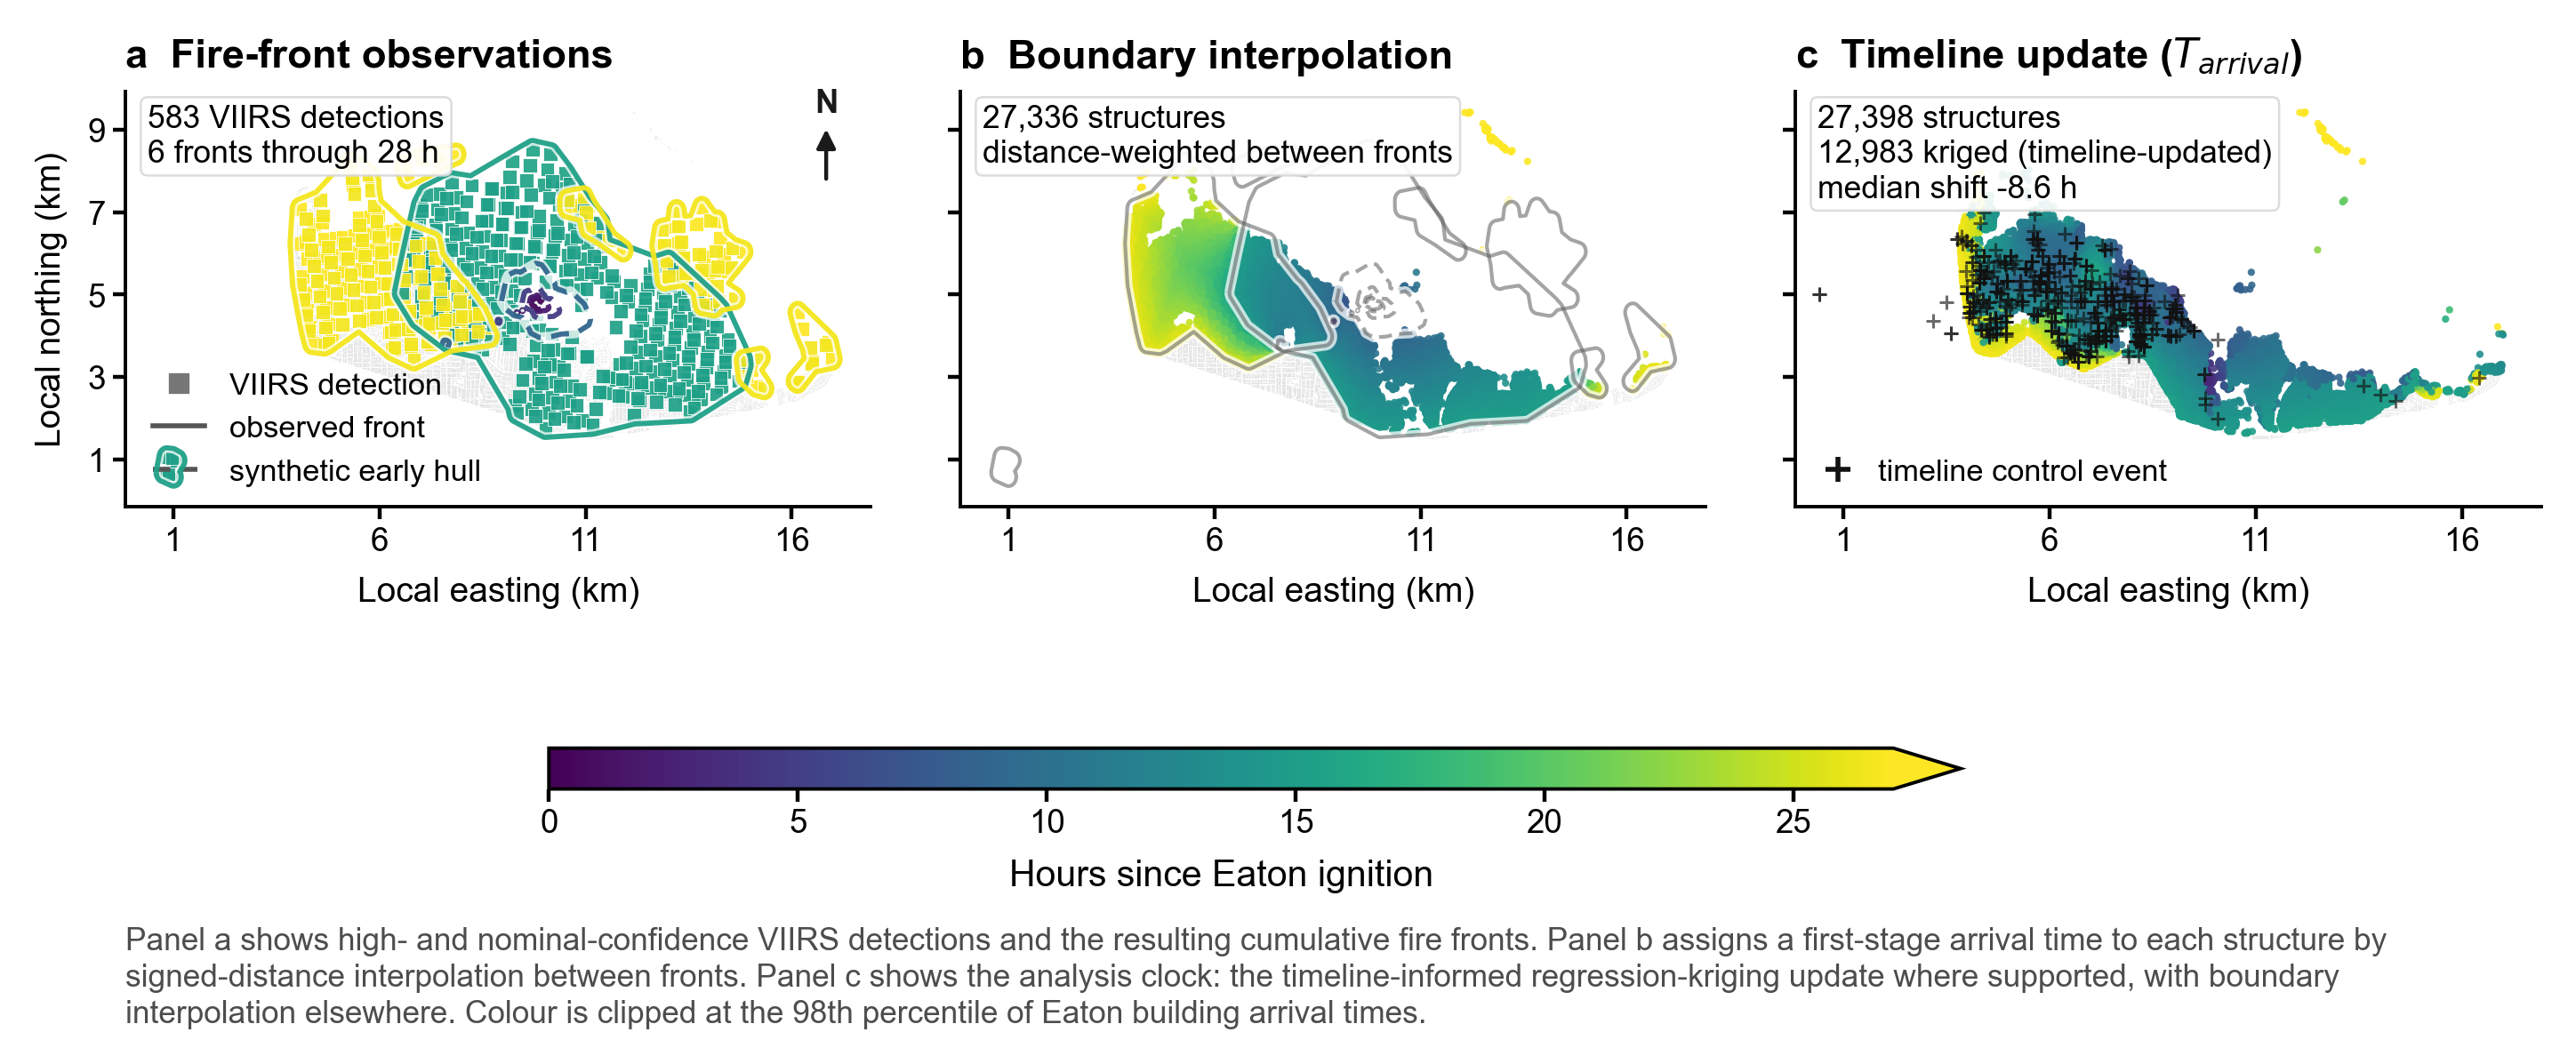

saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/extended_data/ED_fig_eaton_arrival_steps.png


In [5]:
eaton_steps_figure = make_eaton_arrival_steps_figure(
    PROJECT_ROOT, FIGURES, SOURCE_DATA)
display(Image(filename=str(eaton_steps_figure), width=950))
print('saved', eaton_steps_figure)

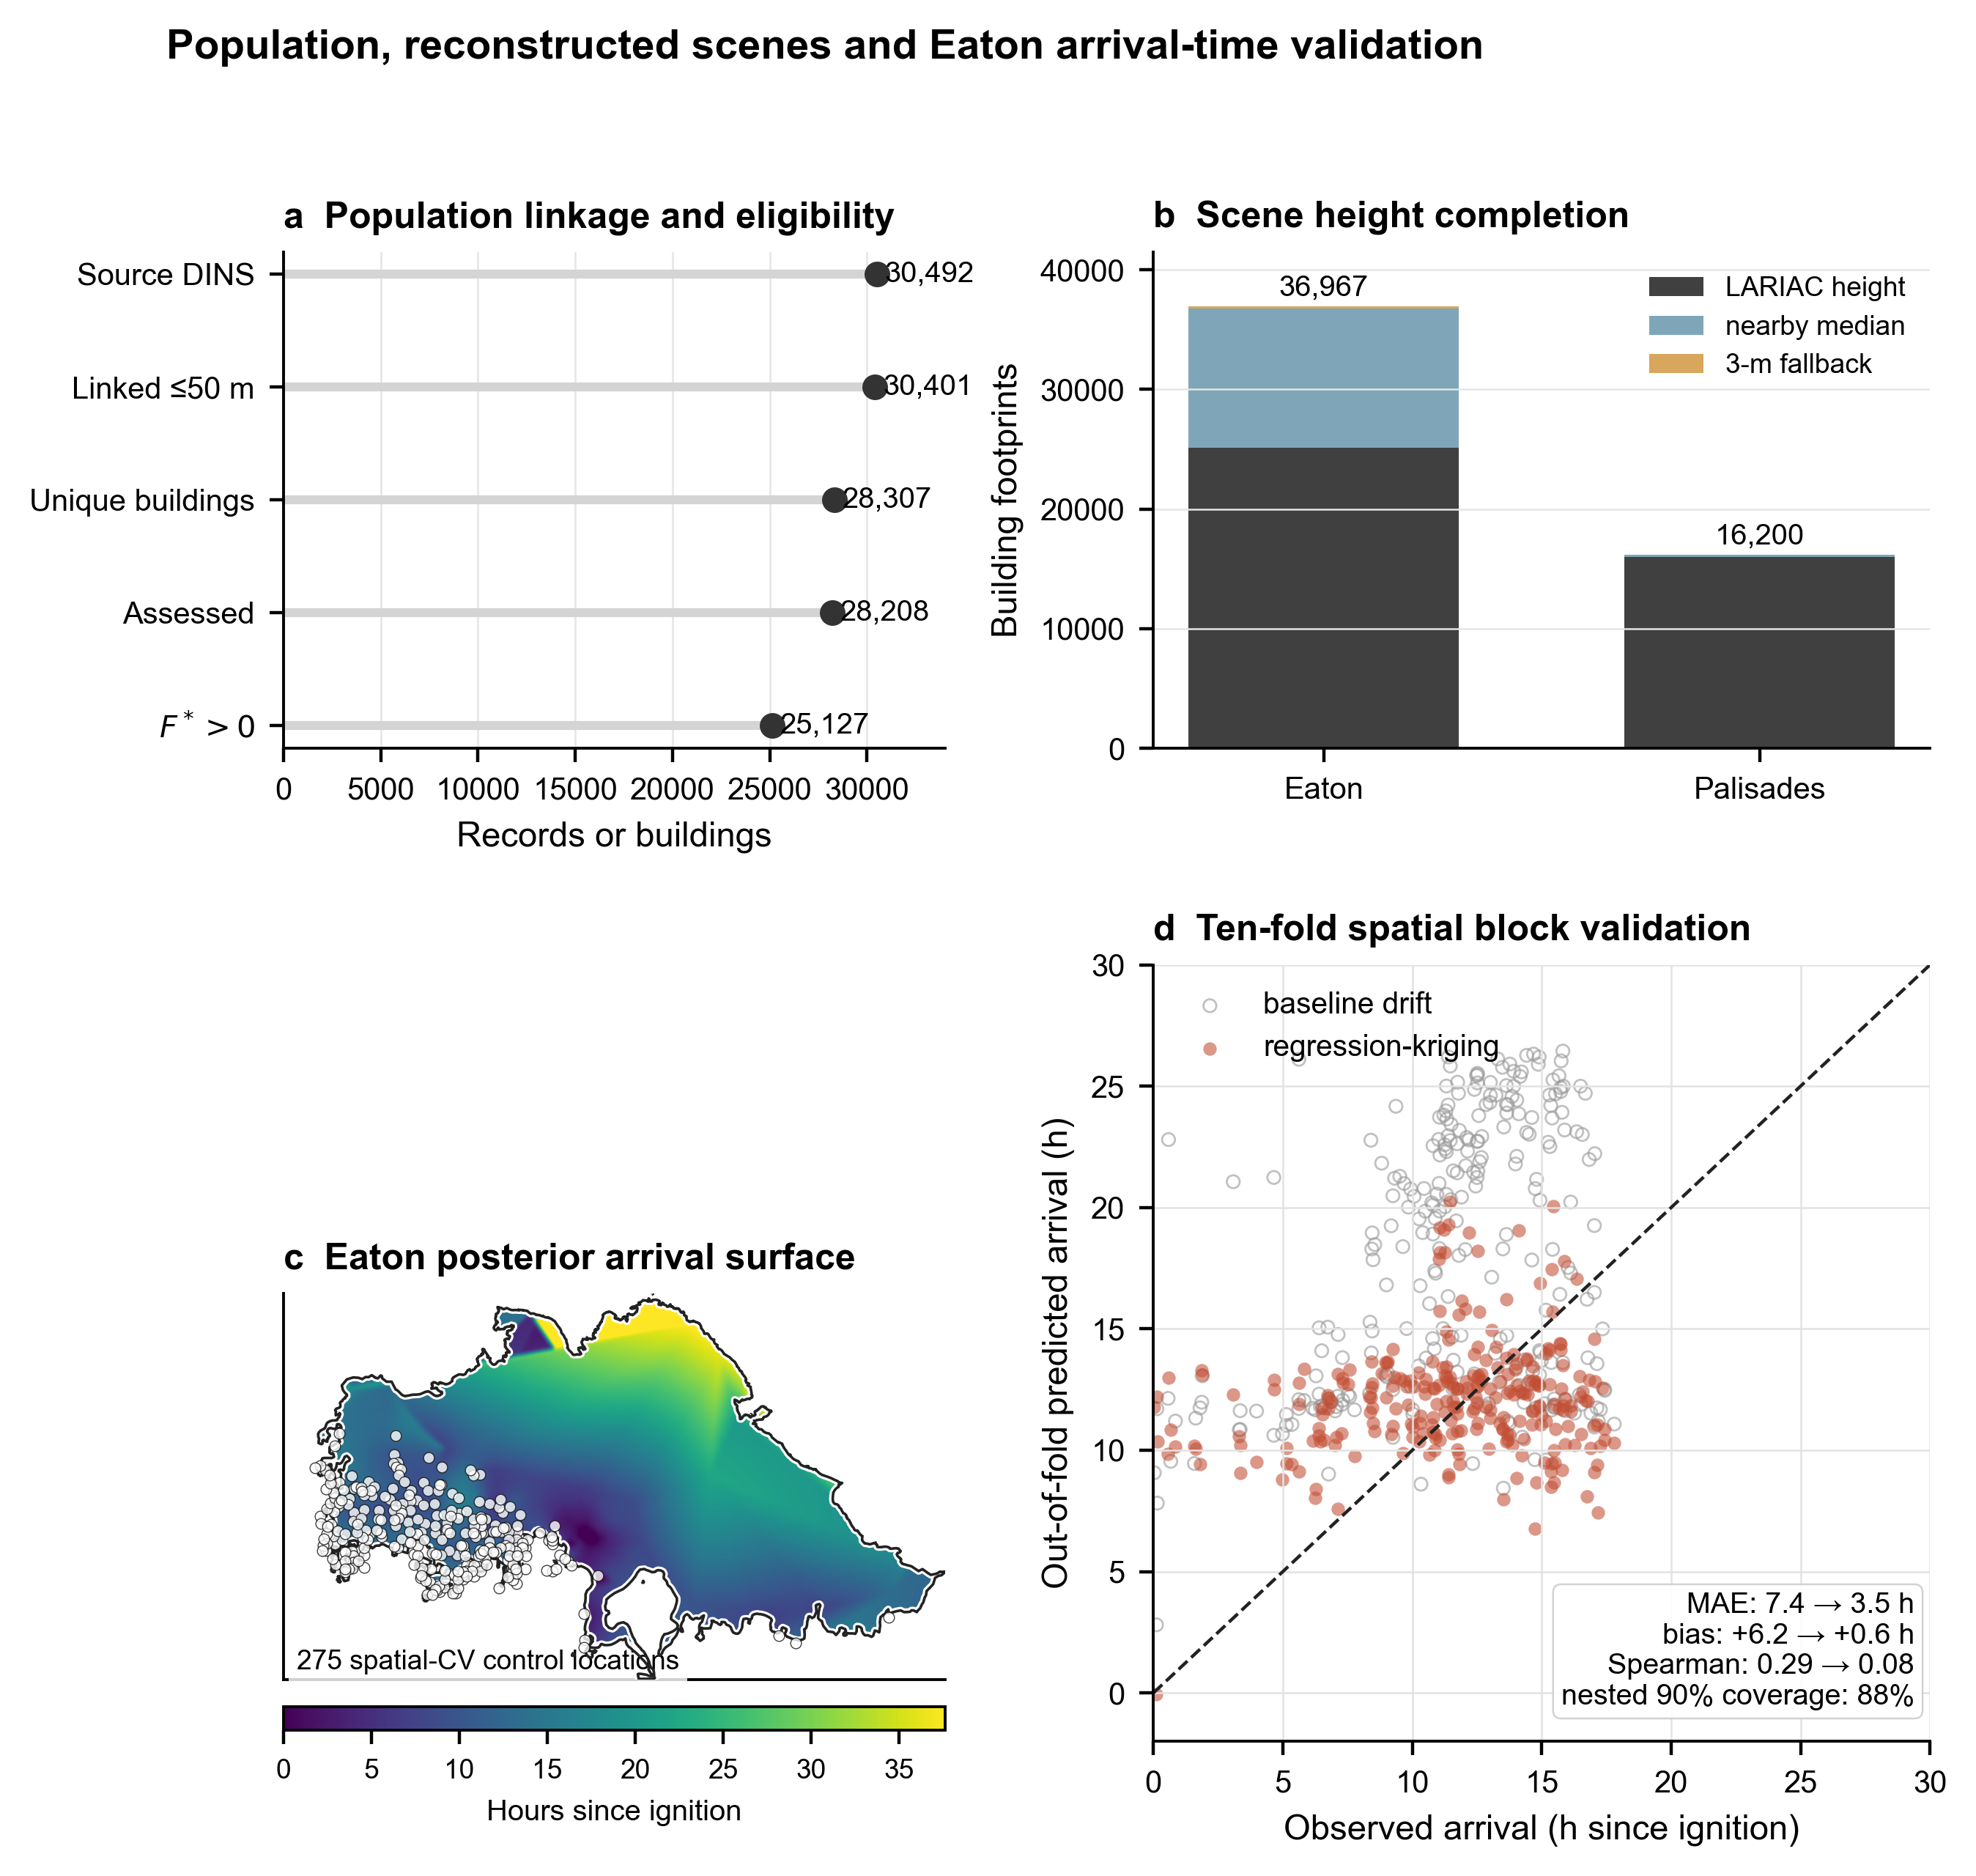

saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/extended_data/ED_fig_population_scene_arrival.png


In [6]:
figure_path = make_ed01_figure(PROJECT_ROOT, RESULTS, FIGURES)
display(Image(filename=str(figure_path), width=950))
print('saved', figure_path)

### Arrival reconstruction figure

**Extended Data Fig. | Rebuilding the per-structure arrival clock.** All mapped fields are rebuilt from the packaged isochrones and incident timeline. **a**,**d**, Observed fire fronts: 583 high- and nominal-confidence VIIRS detections and the six cumulative Eaton fronts they define through 33 h (dashed, synthetic early hulls), and 4 of 11 Palisades progression tiles unioned into nested fronts. **b**,**e**, Signed-distance interpolation between successive fronts gives each structure a first-stage arrival time, `T_arrival_interp_hrs` (27,336 Eaton; 9,990 Palisades). **c**, The analysis clock, `T_arrival_hrs`: a regression-kriging posterior fitted to post-ignition timeline events replaces the interpolation for 12,983 of 27,398 Eaton structures, a median shift of −8.6 h. Palisades has no timeline update, so **e** is its final clock. Color encodes each arrival time as its percentile within its own fire's structure arrival distribution; the underlying hours are heavily skewed and would compress most structures into a narrow band.

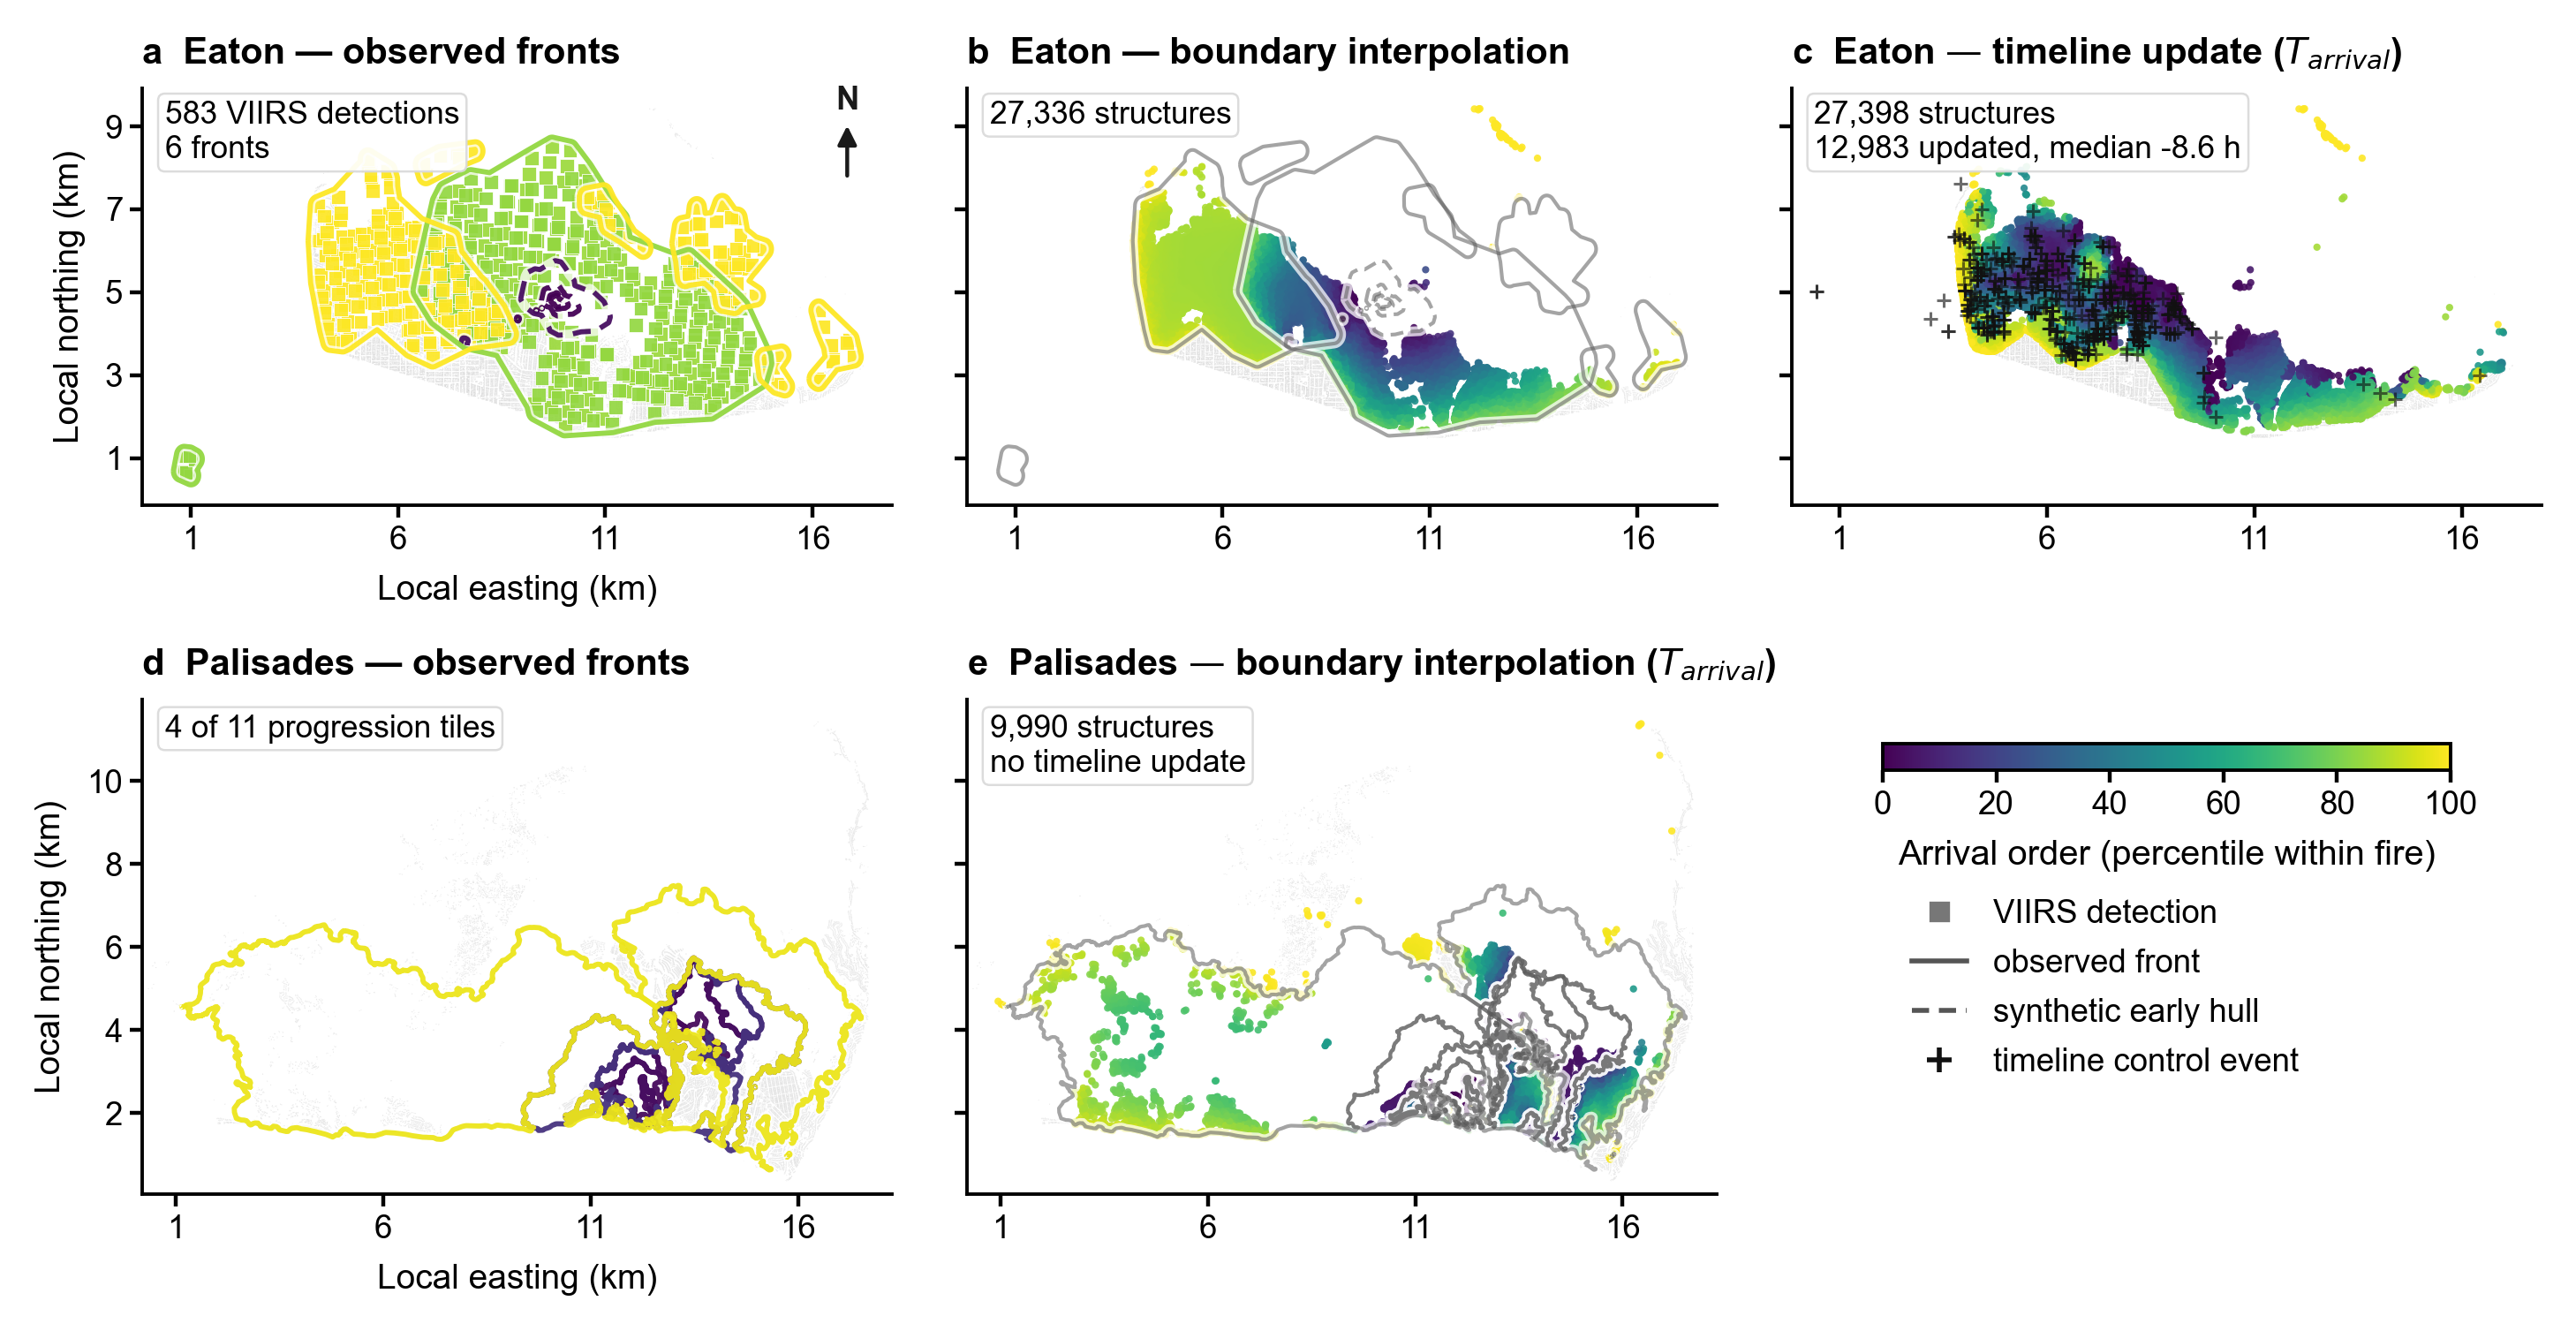

saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/extended_data/ED_fig_arrival_reconstruction.png


In [7]:
reconstruction_figure = make_arrival_reconstruction_figure(
    PROJECT_ROOT, RESULTS, FIGURES, SOURCE_DATA)
display(Image(filename=str(reconstruction_figure), width=950))
print('saved', reconstruction_figure)

## Interpretation

Rebuilding the isochrone interpolation and refitting the Eaton posterior reproduces the distributed arrival fields and the frozen posterior raster to floating-point identity, so the packaged arrival clock carries no hidden adjustment. The final reconstruction retains all mapped footprints as physical occluders or emitters and assigns positive heights to every building. For Eaton, the timeline-informed regression-kriging update removes most of the positive timing bias in the baseline surface and reduces out-of-fold mean absolute error, but does not improve rank concordance across held-out spatial blocks. The calibrated interval represents spatial prediction uncertainty; arrival time is therefore treated as an estimated ordering variable rather than a direct observation at every building, and arrival-restricted exposure is used as a sensitivity analysis rather than the primary exposure definition.

In [8]:
manifest = population['manifest']['analysis_population']
selected = arrival['eaton_arrival_cv'].query('selected').iloc[0]
assert manifest['assessed'] == 28_208
assert manifest['positive_F_star'] == 25_127
assert population['height_imputation'].miseng_final_height.sum() == 0
assert selected.mae_h < arrival['eaton_arrival_baseline'].mae_h.iloc[0]
assert 0.85 <= selected.nested_cv_90_coverage <= 0.95
agreement = reconstruction['packaged_agreement'].set_index('field')
assert agreement.loc['T_arrival_hrs', 'compared'] == 37_388
assert agreement.loc['T_arrival_hrs', 'max_abs_diff_h'] < 1e-6
assert agreement.loc['T_arrival_interp_hrs', 'max_abs_diff_h'] < 1e-6
assert agreement.loc['arrival_method', 'exact_match_share'] == 1
assert reconstruction['posterior_raster_agreement'].max_abs_diff_h.max() < 1e-6
print('PASS: ED01 population, scene, arrival reconstruction and validation checks')

PASS: ED01 population, scene, arrival reconstruction and validation checks
